# Demo: Analysing Land Surface Temperature Data from the Climate Data Store in xcube

First, we import some necessary libraries and configure some matplotlib display preferences.

In [1]:
# Imports
from xcube.core.store import new_data_store
import matplotlib.pyplot as plt
import pandas as pd


# Plot settings
%matplotlib inline

Create a CDS data store object. The optional `normalize_names` parameter specifies that variable names in returned data cubes will be converted to legal Python identifiers, if required.

In [2]:
cds_store = new_data_store("cds", normalize_names=True)

First we list the available data sets from the store to ensure the correct id is included. We are looking for `satellite-land-surface-temperature`.

In [3]:
data_ids = list(cds_store.get_data_ids())
data_ids

['reanalysis-era5-land',
 'reanalysis-era5-land-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels:ensemble_mean',
 'reanalysis-era5-single-levels:ensemble_members',
 'reanalysis-era5-single-levels:ensemble_spread',
 'reanalysis-era5-single-levels:reanalysis',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_ensemble_members',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels-timeseries',
 'satellite-soil-moisture:saturation:daily',
 'satellite-soil-moisture:saturation:10-day',
 'satellite-soil-moisture:saturation:monthly',
 'satellite-soil-moisture:volumetric:daily',
 'satellite-soil-moisture:volumetric:10-day',
 'satellite-soil-moisture:volumetric:monthly',
 'satellite-sea-ice-thickness:envisat',
 'satellite-sea-ice-thickness:cryosat-2',
 'derived-drought-historical-monthly:reanalysis',
 'derived-drought-historical-monthly:ensemble_members',
 'satellite-land-cover',
 'satellite-land-surfa

In [4]:
data_id =  "satellite-land-surface-temperature"
data_id in data_ids

True

If it is there, all is well and we can proceed. It is good practice to have a look at the opening parameters before opening a dataset.

In [5]:
cds_store.get_open_data_params_schema(data_id)

We see that there are is one parameter that we need to pass - `time_range` - and two optional ones - `bbox`and `observation_time`. The default values for `observation_time` is `day`, which is fine. However, as the data comes in a rather high spatial resolution of 0.01 degrees, we just ask for a subset. We pick the Makgadikgadi Pans National Park in Botsuana. As time range, we select values from January to June of a random year.

In [6]:
lst_data = cds_store.open_data(
    "satellite-land-surface-temperature",
    time_range=["2006-01-01", "2006-06-30"],
    bbox=[25, -21, 26, -20]
)
lst_data

xcube-cds version 1.2.0
2026-03-05 13:45:21,211 INFO Request ID is 3128afb6-cde8-400d-b226-888c6309a06b
2026-03-05 13:45:21,278 INFO status has been updated to accepted
2026-03-05 13:45:27,684 INFO status has been updated to running
2026-03-05 13:45:32,843 INFO status has been updated to successful
                                                                                

<xarray.Dataset> Size: 3MB
Dimensions:          (time: 6, lat: 100, lon: 100, length_scale: 1, channel: 2)
Coordinates:
  * time             (time) datetime64[ns] 48B 2006-01-01 ... 2006-06-01
  * lat              (lat) float32 400B -21.0 -20.98 -20.98 ... -20.02 -20.01
  * lon              (lon) float32 400B 25.0 25.01 25.02 ... 25.98 25.98 25.99
  * channel          (channel) float32 8B 11.0 12.0
Dimensions without coordinates: length_scale
Data variables: (12/14)
    dtime            (time, lat, lon) timedelta64[ns] 480kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    satze            (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    sataz            (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    solze            (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    solaz            (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    lst              (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    ...               ...
    lst_unc_loc_atm  (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    lst_unc_loc_sfc  (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    lst_unc_sys      (time, length_scale) float32 24B dask.array<chunksize=(1, 1), meta=np.ndarray>
    lcc              (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    n                (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    lst_unc_loc_cor  (time, lat, lon) float32 240kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
Attributes: (12/42)
    title:                      ESA LST CCI land surface temperature data at ...
    institution:                University of Leicester
    history:                    Created using software developed at Universit...
    references:                 https://climate.esa.int/en/projects/land-surf...
    Conventions:                CF-1.8
    product_version:            3.00
    ...                         ...
    spatial_resolution:         0.01 degree
    source:                     ESA LST CCI ATSR_3 L3S V3.00
    summary:                    This file contains level L3S global land surf...
    doi:                        10.5285/b8be3f3993e54d309fddf61ea5d3674f
    platform:                   Envisat
    sensor:                     AATSR

This dataset provides us with a total of 14 different variables. For now, we are most interested in plotting the land surface temperature in `lst`. The simplest way to do so is like this:

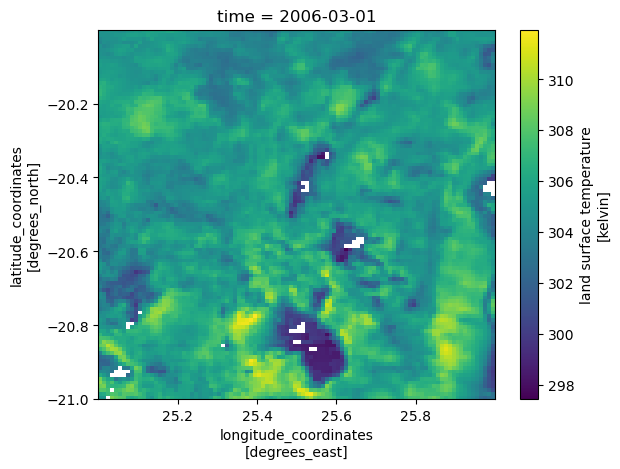

In [7]:
lst_data.lst.sel(time="2006-03-01 00:00:00", method="nearest").plot()

Now that we see the data looks okay, we can work on the visualisation and define a helper function. The function below provides default values for
- the time step (one of the six months from January to June)
- the variable (in case we want to plot something other than `lst`)
- the color scale (which is scaled to values that can be found in the selected region)
- an option to convert the unit from kelvin to celsius (default is false)
- a color map that is better apt to display temperatures
- a figure size

In [8]:
kelvin_color_scale = (285, 320)
celsius_color_scale = (10, 45)

def plot_temperature(data, timestep=0, variable="lst", color_scale=(None, None), convert_to_celsius=False, cmap="coolwarm", figsize=(14, 12)):
    data_array = data[variable].isel(time=timestep)    

    if convert_to_celsius:
        data_array = data_array - 273.15
        data_array.attrs = data[variable].attrs
        data_array.attrs["units"] = "celsius"
        color_scale = color_scale or celsius_color_scale

    color_scale = color_scale or kelvin_color_scale

    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.pcolormesh(
        data.lon,
        data.lat,
        data_array,
        vmin=color_scale[0], 
        vmax=color_scale[1],
        cmap=cmap
    )    
    ax.set_xlabel(f"{data.lon.attrs['long_name']} [{data.lon.attrs['units']}]")
    ax.set_ylabel(f"{data.lat.attrs['long_name']} [{data.lat.attrs['units']}]")

    timestamp = pd.Timestamp(data.time[timestep].values)

    variable_name = data[variable].attrs.get('long_name', variable)
    
    ax.set_title(f"{variable_name} in {timestamp.month_name()}, {timestamp.year}")

    cbar = fig.colorbar(im, ax=ax)    
    cbar.set_label(f"{data[variable].attrs['long_name']} [{data[variable].attrs['units']}]")

    plt.show()

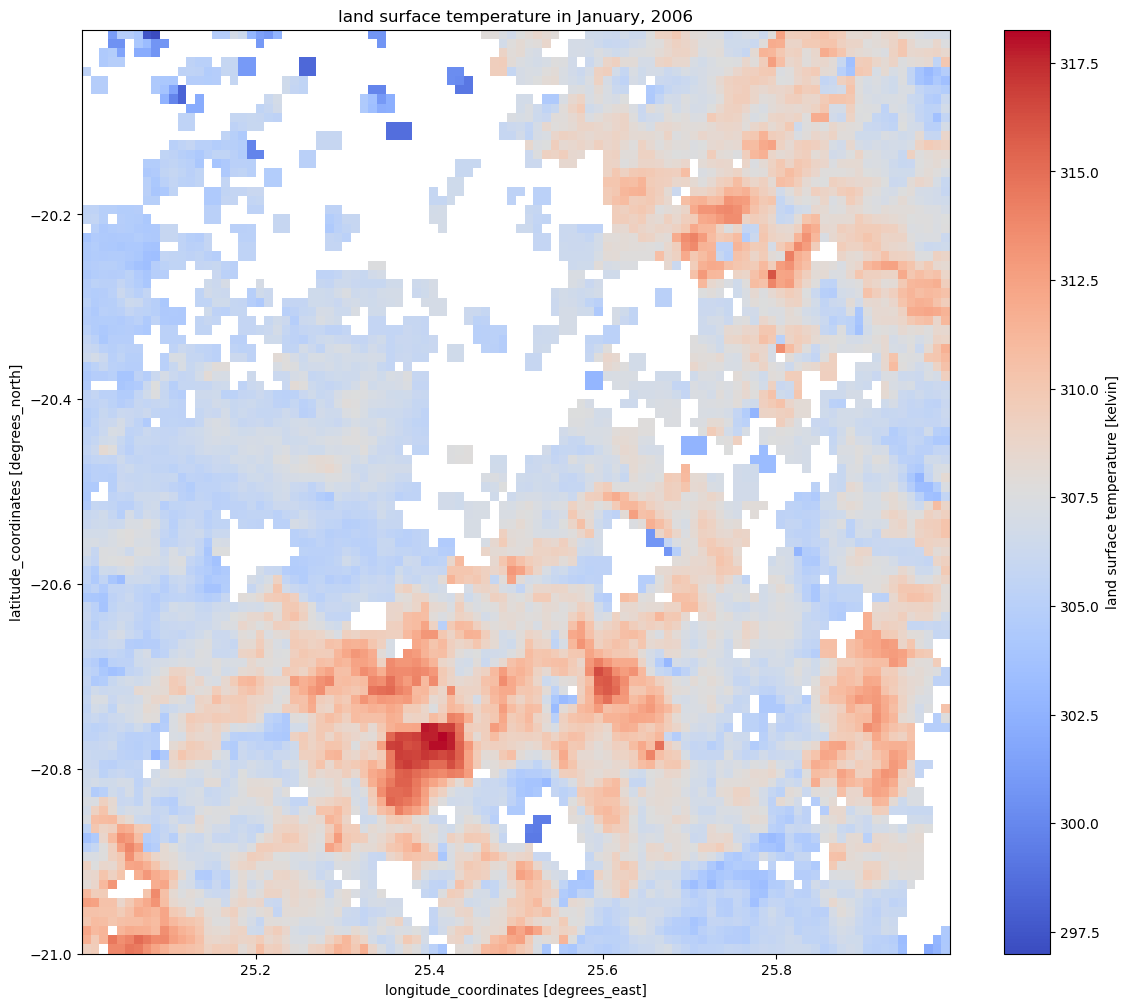

In [9]:
plot_temperature(lst_data)

We may now call this function with some of the defined parameters to see their effect.

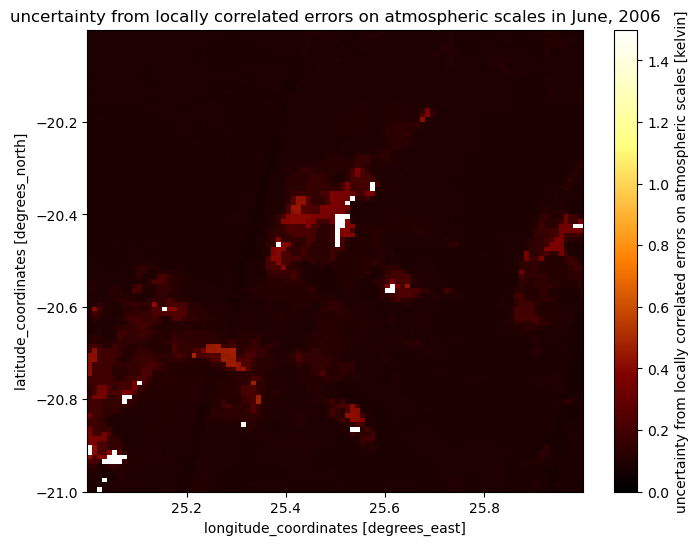

In [10]:
plot_temperature(lst_data, timestep=5, variable="lst_unc_loc_atm", color_scale=(0, 1.5), cmap="afmhot", figsize=(8, 6))

... or, to show the conversion to celsius:

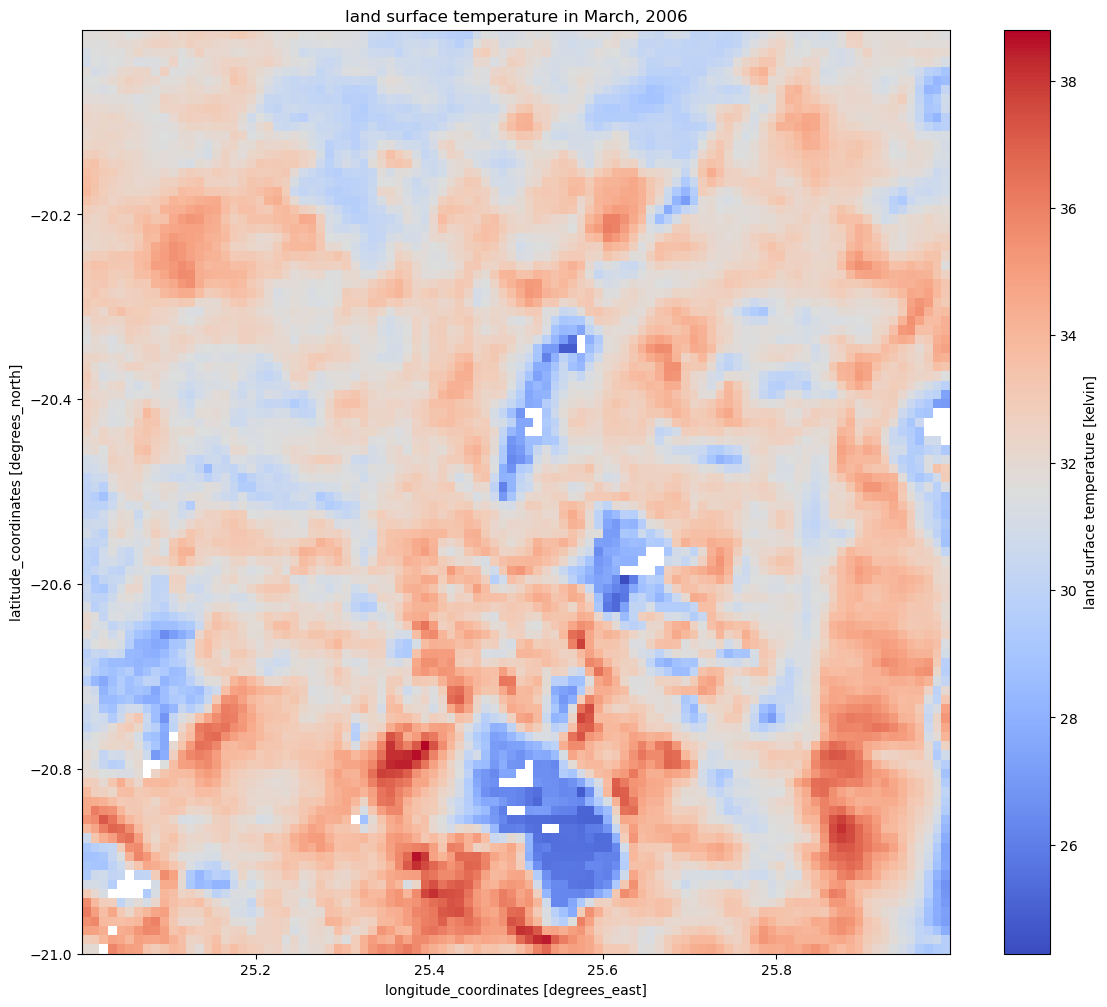

In [11]:
plot_temperature(lst_data, timestep=2, convert_to_celsius=True)

We see that there are many uncertainty variables that comes with the dataset. We already plotted one of them, but we can easily extend our method to plot it together with the `lst` variable:

In [12]:
kelvin_color_scale = (285, 320)
celsius_color_scale = (10, 45)

def plot_lst_with_unc(data, timestep=0, color_scale=(None, None), convert_to_celsius=False, cmap="coolwarm", figsize=(14, 12), unc_var="lst_uncertainty", unc_max=6.5):
    data_array = data["lst"].isel(time=timestep)    

    if convert_to_celsius:
        data_array = data_array - 273.15
        data_array.attrs = data["lst"].attrs
        data_array.attrs["units"] = "celsius"
        color_scale = color_scale or celsius_color_scale

    color_scale = color_scale or kelvin_color_scale

    unc = 1 - data[unc_var].isel(time=timestep) / unc_max
    unc = unc.fillna(1)

    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.pcolormesh(
        data.lon,
        data.lat,
        data_array,
        vmin=color_scale[0], 
        vmax=color_scale[1],
        cmap=cmap,
        alpha=unc
    )    
    ax.set_xlabel(f"{data.lon.attrs['long_name']} [{data.lon.attrs['units']}]")
    ax.set_ylabel(f"{data.lat.attrs['long_name']} [{data.lat.attrs['units']}]")

    timestamp = pd.Timestamp(data.time[timestep].values)

    variable_name = data["lst"].attrs.get('long_name', "lst")
    
    ax.set_title(f"{variable_name} in {timestamp.month_name()}, {timestamp.year}")

    cbar = fig.colorbar(im, ax=ax)    
    cbar.set_label(f"{data["lst"].attrs['long_name']} [{data["lst"].attrs['units']}]")

    plt.show()

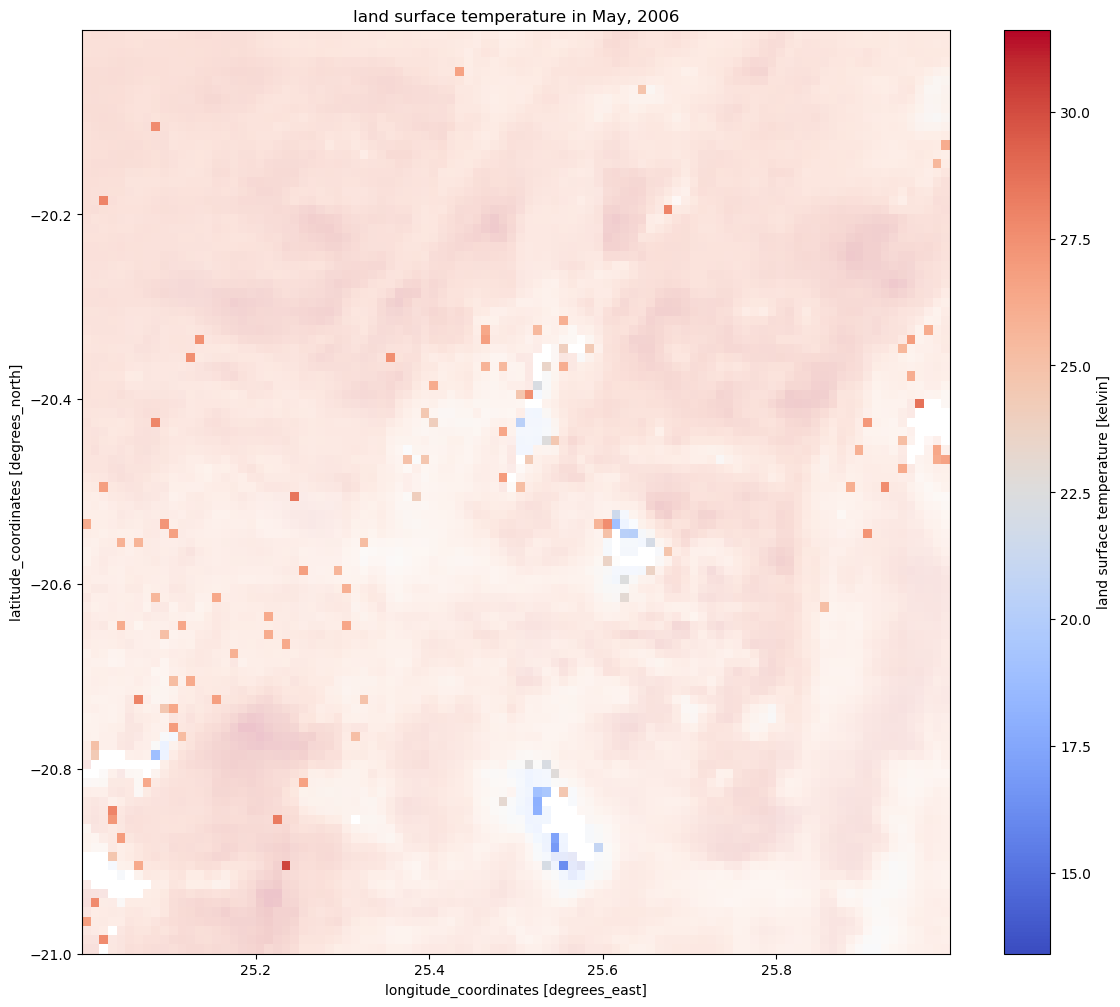

In [13]:
plot_lst_with_unc(lst_data, timestep=4, convert_to_celsius=True)